In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from nn_helpers import *
from spectra import MoogStokesModel

## Create parameters to sample

Before we do anything else, we need to deal with the fact that Teff ~ 10^4 while
other parameters are closer to 1. Use the ParamScaler class to normalize the parameters.

In [171]:
# For example,
scaler = ParamScaler()
p_physical = {"Teff": 4000, "logg": 4.25, "vsini": 37, "B": 1.0}
p_nn = scaler.physical_to_nn(p_physical)
print("Physical parameters:", p_physical)
print("NN parameters:", p_nn)

# We can go backwards like this:
p_physical_recovered = scaler.nn_to_physical(p_nn)
print("Recovered physical parameters:", p_physical_recovered)

Physical parameters: {'Teff': 4000, 'logg': 4.25, 'vsini': 37, 'B': 1.0}
NN parameters: {'Teff': np.float64(-2.0), 'logg': np.float64(0.5), 'vsini': np.float64(1.25), 'B': np.float64(-1.0)}
Recovered physical parameters: {'Teff': np.float64(4000.0), 'logg': np.float64(4.25), 'vsini': np.float64(37.0), 'B': np.float64(1.0)}


Now, we will generate the model parameters that should be used to create the radiative transfer models.
These parameters are saved to a TXT file so that they can be imported later.

In [172]:
fname_params = "model_params_to_generate.txt"
m_sobol = 12
N_params = 4      # ignore veiling
seed = 287

# Define the lower and upper bounds for the generated parameters
p_lower = {
    "Teff": 3000,
    "vsini": 2,
    "logg": 2.25,
    "B": 0.0
}

p_upper = {
    "Teff": 7000,
    "vsini": 57,
    "logg": 5.25,
    "B": 3.0
}
print("Number of models: ", 2**m_sobol)

param_samples_phys, param_samples_nn = make_sobol_samples(N_params, m_sobol, p_lower, p_upper, fname_params, seed)

Number of models:  4096


In [176]:
N_test

409

In [173]:
params_samples_phys = np.loadtxt(fname_params, skiprows=1)

p_train = 0.85  # fraction of data to use for training
p_val = 0.05    # validation, which refers to tuning the hyperparameters
p_test = 1 - p_train - p_val  # final testing

fname_train = "data/train_params.txt"
fname_val = "data/val_params.txt"
fname_test = "data/test_params.txt"

# Divide up the data by shuffling indices
N_models = len(params_samples_phys)
N_train = round(N_models * p_train)
N_val = round(N_models * p_val)
N_test = N_models - N_train - N_val

seed = 287
indices = np.arange(N_models)
np.random.seed(seed)
np.random.shuffle(indices)

train_indices = indices[:N_train]
val_indices = indices[N_train:N_train + N_val]
test_indices = indices[N_train + N_val:]

# save_params_to_txt(params_samples_phys[train_indices], fname_train)
# save_params_to_txt(params_samples_phys[val_indices], fname_val)
# save_params_to_txt(params_samples_phys[test_indices], fname_test)

In [9]:
# Split each set of parameters further depending on the value of Teff for piecewise
# interpolation

fname_train_cool = "data/train_params_cool.txt"
fname_train_hot = "data/train_params_hot.txt"
fname_val_cool = "data/val_params_cool.txt"
fname_val_hot = "data/val_params_hot.txt"
fname_test_cool = "data/test_params_cool.txt"
fname_test_hot = "data/test_params_hot.txt"

def split_params_by_teff(fname_in, fname_cool, fname_hot, teff_lo, teff_hi):
    # teff_threshold
    params = np.loadtxt(fname_in, skiprows=1)
    cool_params = params[params[:, 0] < teff_hi]  # between hi and lo is the overlap region
    hot_params = params[params[:, 0] >= teff_lo]
    save_params_to_txt(cool_params, fname_cool)
    save_params_to_txt(hot_params, fname_hot)

teff_lo = 3400
teff_hi = 3600
split_params_by_teff(fname_train, fname_train_cool, fname_train_hot, teff_lo, teff_hi)
split_params_by_teff(fname_val, fname_val_cool, fname_val_hot, teff_lo, teff_hi)
split_params_by_teff(fname_test, fname_test_cool, fname_test_hot, teff_lo, teff_hi)

Verify the distribution of parameters by plotting them.

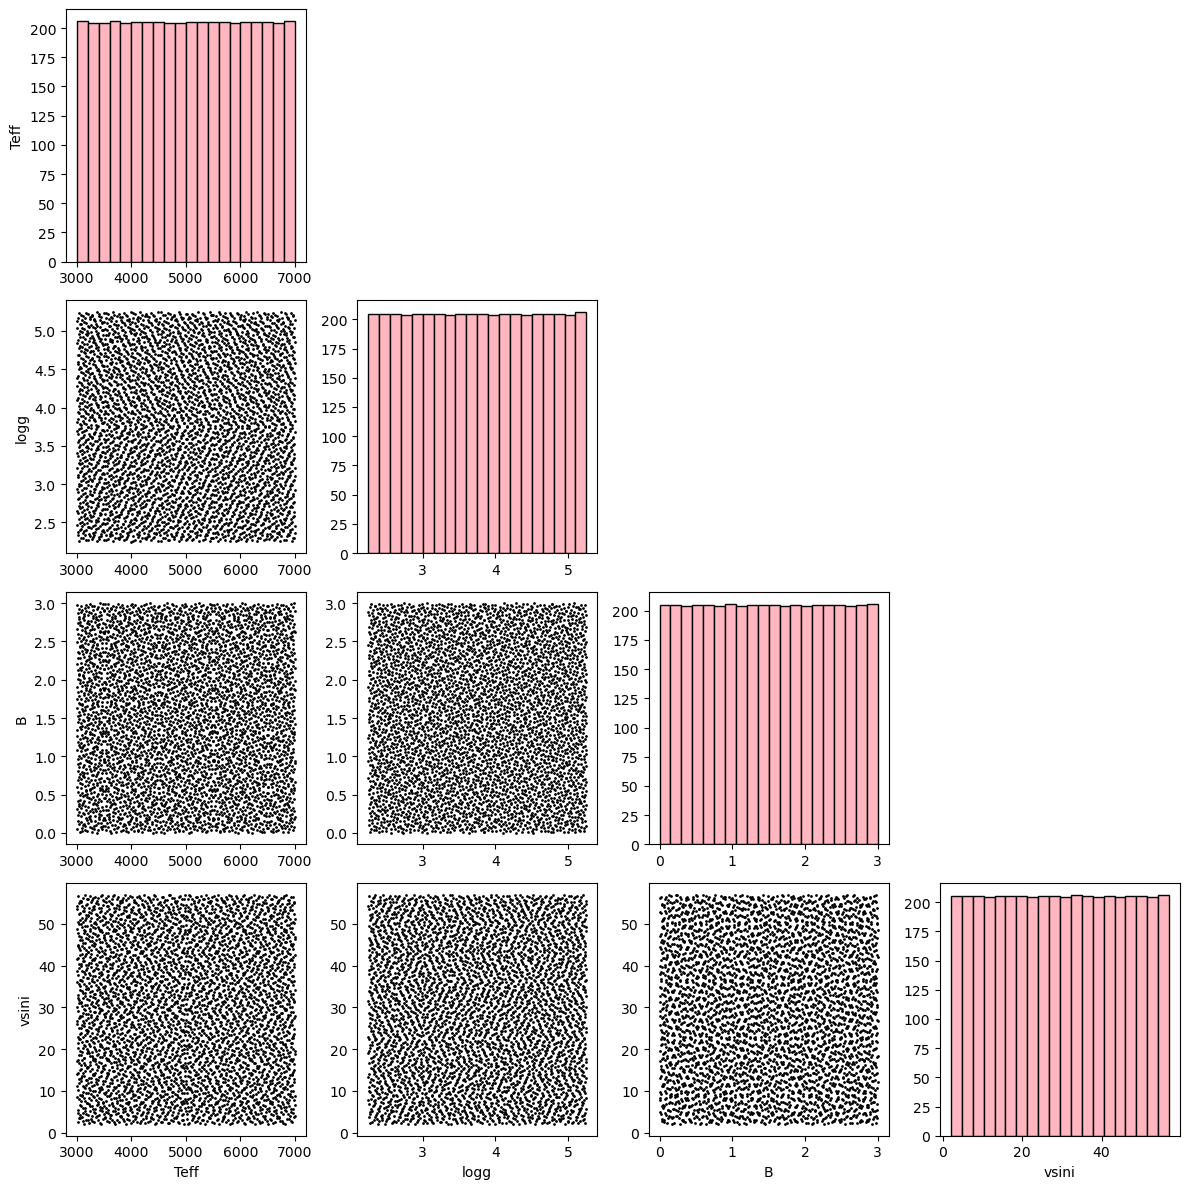

In [9]:
fig, axs = plt.subplots(N_params, N_params, figsize=(12, 12))

param_names = scaler.param_order

for i in range(N_params):
    for j in range(N_params):
        if i == j:
            axs[i, j].hist(param_samples_phys[:, i], bins=20, color='lightpink', edgecolor='black')
        elif i < j:
            axs[i, j].axis("off")
            continue

        else:
            axs[i, j].scatter(param_samples_phys[:, j], param_samples_phys[:, i], s=1, c='k')
        # Labels
        if j == 0:
            axs[i, j].set_ylabel(param_names[i])
        if i == N_params - 1:
            axs[i, j].set_xlabel(param_names[j])

plt.tight_layout()
plt.show()


## Generate training data
For the test, I will use linear interpolation. This should be replaced by the actual MoogStokes radiative transfer models.

In [3]:
from interpolate_moogstokes import check_moogstokes_grid_rectangularity, interpolate_moogstokes_to_points

interpolation_bounds = {
    "Teff":  (3000, 7000),
    "logg":  (2.5, 5.25),
    "B":     (0, 3.0),
    "vsini": (2, 42),
}

check_moogstokes_grid_rectangularity(
    "data/moog-stokes/",
    interpolation_bounds,
)

AttributeError: partially initialized module 'pandas' from '/Users/ellenlee/opt/anaconda3/envs/playground/lib/python3.13/site-packages/pandas/__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [5]:
fname_params = "model_params_to_generate.txt"
params_samples_phys = np.loadtxt(fname_params, skiprows=1)

region_sizes = np.zeros(7, dtype=int)

for r in range(7):
    interpolate_moogstokes_to_points(
        models_dir = "data/moog-stokes/",
        output_dir = "data/moog-stokes-itp/",
        region = r,
        target_params = params_samples_phys,
        interpolation_bounds = interpolation_bounds,
        verbose = True
    )

    # Also check how many wavelength points are in each region. We need this
    # to create the neural network output layer

    testmodel = MoogStokesModel(
        Teff = params_samples_phys[0, 0],
        logg=params_samples_phys[0, 1],
        rK = 0,
        B = params_samples_phys[0, 2],
        vsini = params_samples_phys[0, 3],
        region = r
        )
    
    region_sizes[r] = len(testmodel.x)

NameError: name 'interpolate_moogstokes_to_points' is not defined

In [13]:
print(region_sizes)
with open("data/region_sizes.txt", "w") as f:
    f.write("# region size\n")
    for r in range(7):
        f.write(f"{r} {region_sizes[r]}\n")

[1099  548  518  688 1399  849 1231]


Set up a file that will contain the 4 input parameters and the file name.
This will be used as an input the pytorch dataset class. Divide the models into
a training, validation, and testing dataset.

## Train a neural network

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(DEVICE)

cpu


### Some data cleanup

In [61]:
# not all xlengths are the same, so we need to truncate them to match the shortest
# one (removing the end of the spectrum)
for r in range(7):
    testdata = MoogStokesTorchDataset(fname_test, region=r)

    xlengths = []
    for fn in testdata.fnames:
        spec = np.loadtxt(fn).T
        if spec.shape[1] not in xlengths:
            xlengths.append(spec.shape[1])

    print(xlengths)

    xlenmin = min(xlengths)
    for fn in testdata.fnames:
        spec = np.loadtxt(fn).T
        if spec.shape[1] != xlenmin:
            specnew = spec[:, :xlenmin]
            np.savetxt(fn, specnew.T)

[1099]
[548]
[519]
[688]
[1399]
[849]
[1231]


In [63]:
# Save a new file storing the region sizes and wavelengths for each region.

with open("data/region_info.txt", "w") as f:
    f.write("# region size xstart xend\n")
    for r in range(7):
        testdata = MoogStokesTorchDataset(fname_test, region=r)
        spec = np.loadtxt(testdata.fnames[0]).T
        xlen = len(spec[0])
        f.write(f"{r} {xlen} {spec[0][0]} {spec[0][-1]}\n")

Text(0.5, 1.0, 'Teff: 3568 K, logg: 4.470, B: 1.877 kG, vsini: 41.786 km/s')

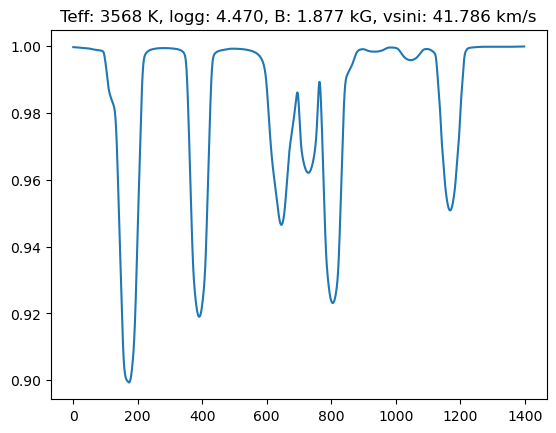

In [24]:
# Show one model from the dataloader to check that it's working
train_params, train_flux = next(iter(dataloader_train))
scaler = ParamScaler()
p_phys = scaler.nn_to_physical(train_params[0].numpy())
plt.figure() 
plt.plot(train_flux[0].numpy())
plt.title(f"Teff: { p_phys[0]:.0f} K, logg: {p_phys[1]:.3f}, B: {p_phys[2]:.3f} kG, vsini: {p_phys[3]:.3f} km/s")

In [25]:
for X, y in dataloader_train:
    print(X.shape, y.shape)
    break

torch.Size([64, 4]) torch.Size([64, 1399])


### Training

In [3]:
def train_nn(fname_train, fname_val, region, epochs, batch_size, arch=SpectralInterpolatorNeuralNetwork,
             loss_fn=nn.MSELoss(), optimizer_cls=torch.optim.Adam, **kwargs):
        
    dataloader_train = DataLoader(
        MoogStokesTorchDataset(fname_train, region=region),
        batch_size = batch_size,
        shuffle = True
    )
    dataloader_val = DataLoader(
        MoogStokesTorchDataset(fname_val, region=region),
        batch_size = batch_size,
        shuffle = False
    )
    print(f"Size of training set: {len(dataloader_train.dataset)}")
    print(f"Size of validation set: {len(dataloader_val.dataset)}")

    Nx = dataloader_train.dataset.num_wavelengths
    Nparams = dataloader_train.dataset.params.shape[1]

    model = arch(num_params=Nparams, num_wavelengths=Nx).to(DEVICE)
    optimizer = optimizer_cls(model.parameters(), **kwargs)

    train_losses = []
    val_losses = []

    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")

        # Training
        size = len(dataloader_train.dataset)
        model.train()

        batch_loss = 0

        for batch, (X, y) in enumerate(dataloader_train):
            X, y = X.to(DEVICE), y.to(DEVICE)

            # Compute prediction error
            pred = model(X)
            loss = loss_fn(pred, y)

            # Backpropagation
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if batch % 20 == 0:
                loss_print, current = loss.item(), (batch + 1) * len(X)
                print(f"loss: {loss_print:>7f}  [{current:>5d}/{size:>5d}]")
            batch_loss += loss.item()
            
        train_losses.append( batch_loss / len(dataloader_train) )

        # Validation
        size = len(dataloader_val.dataset)
        num_batches = len(dataloader_val)
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for X, y in dataloader_val:
                X, y = X.to(DEVICE), y.to(DEVICE)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
        test_loss /= num_batches
        val_losses.append(test_loss)
        print(f"Test Error: Avg loss: {test_loss:>8f}")

    print("Done!")

    return model, train_losses, val_losses
        

In [ ]:
fname_train = "data/train_params.txt"
fname_val = "data/val_params.txt"
fname_test = "data/test_params.txt"


for region in range(7):
    batch_size = 64
    epochs = 400

    # model, train_losses, val_losses = train_nn(fname_train, fname_val, region, epochs=epochs, batch_size=batch_size,
    #                                            optimizer_cls=torch.optim.SGD, lr=0.01, momentum=0.9)
    # model, train_losses, val_losses = train_nn(fname_train, fname_val, region, epochs=epochs, batch_size=batch_size,
    #                                            optimizer_cls=torch.optim.Adam, lr=3e-5)
    model, train_losses, val_losses = train_nn(fname_train, fname_val, region, epochs=epochs, batch_size=batch_size,
                                            optimizer_cls=torch.optim.Adam, lr=1e-5)
    torch.save(model.state_dict(), f"data/nn_region_{region}.pt")

Size of training set: 3482
Size of validation set: 205
Epoch 1
-------------------------------
loss: 1.319293  [   64/ 3482]
loss: 1.166623  [ 1344/ 3482]
loss: 1.032633  [ 2624/ 3482]
Test Error: Avg loss: 0.922486
Epoch 2
-------------------------------
loss: 0.932178  [   64/ 3482]
loss: 0.777140  [ 1344/ 3482]
loss: 0.623191  [ 2624/ 3482]
Test Error: Avg loss: 0.527592
Epoch 3
-------------------------------
loss: 0.531046  [   64/ 3482]
loss: 0.419242  [ 1344/ 3482]
loss: 0.304760  [ 2624/ 3482]
Test Error: Avg loss: 0.243846
Epoch 4
-------------------------------
loss: 0.247528  [   64/ 3482]
loss: 0.171870  [ 1344/ 3482]
loss: 0.143305  [ 2624/ 3482]
Test Error: Avg loss: 0.111219
Epoch 5
-------------------------------
loss: 0.113413  [   64/ 3482]
loss: 0.090186  [ 1344/ 3482]
loss: 0.067567  [ 2624/ 3482]
Test Error: Avg loss: 0.061573
Epoch 6
-------------------------------
loss: 0.065172  [   64/ 3482]
loss: 0.053348  [ 1344/ 3482]
loss: 0.046718  [ 2624/ 3482]
Test Error

KeyboardInterrupt: 

/var/folders/pv/dz5xq3sj059bg3y61lpq5r4r0000gn/T/ipykernel_71321/528543497.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,  0.01)


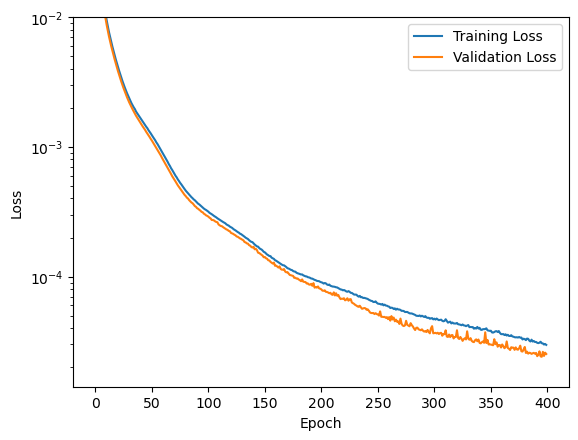

In [52]:
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.ylim(0,  0.01)
plt.legend() 
plt.show()

## Verify the performance of the NN

In [3]:
moognn = MoogStokesNN()

fname_test = "data/test_params.txt"
#fname_test = "data/test_params_hot.txt"
#fname_test = "data/test_params.txt"

region = 5
data_test = MoogStokesTorchDataset(fname_test, region=region)


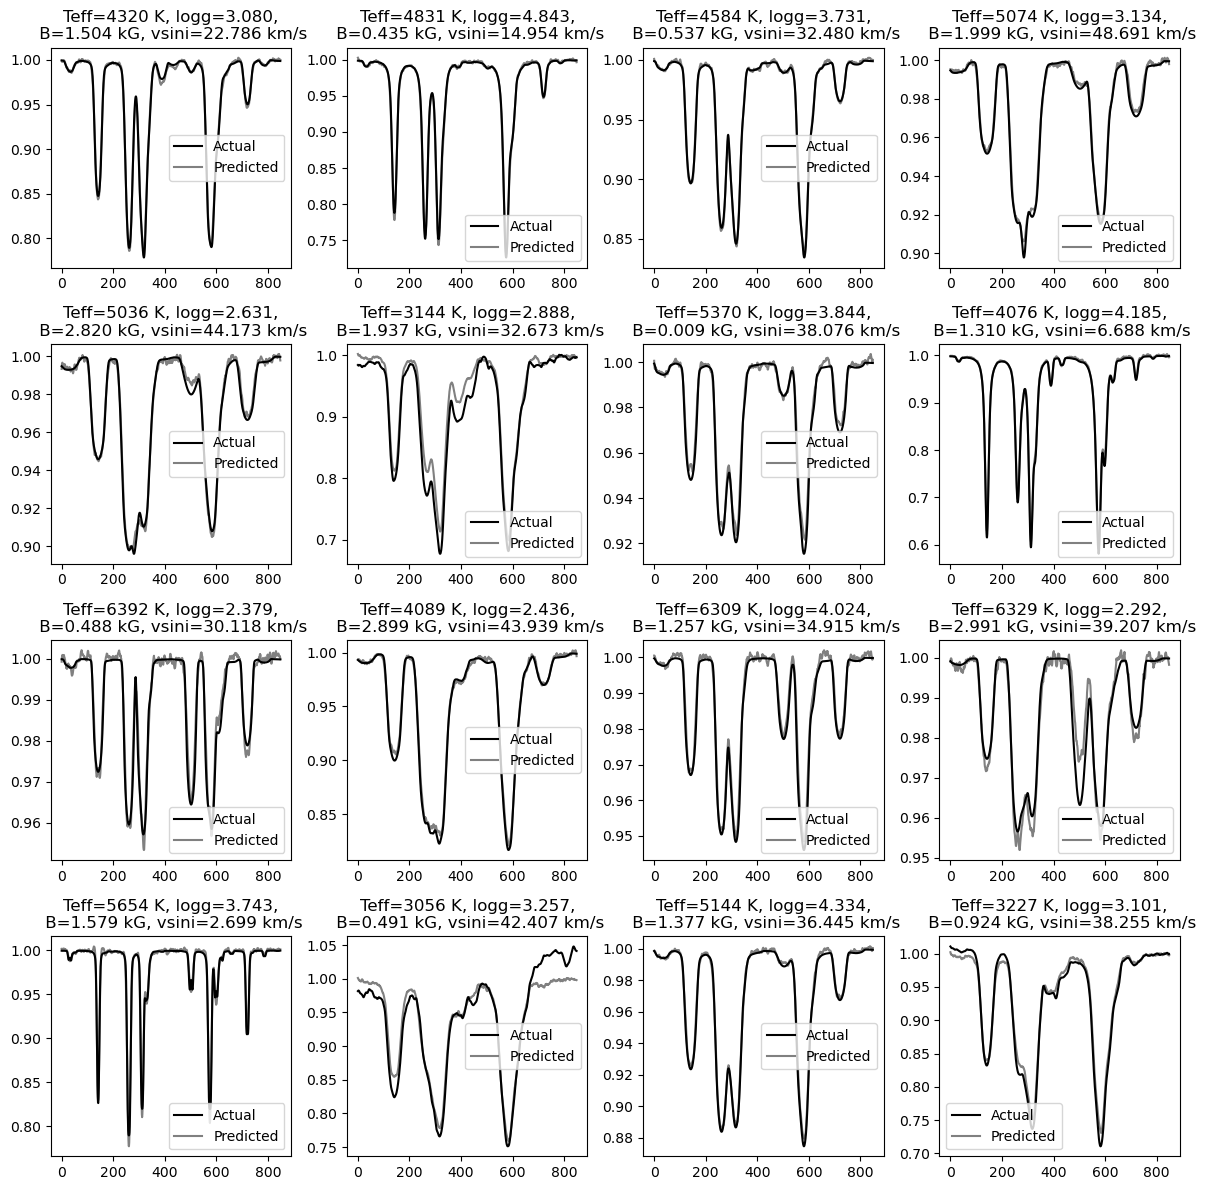

In [8]:
# Randomly plot a sample of 16 models from the test set
scaler = ParamScaler()

from scipy.signal import savgol_filter

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i in range(4):
    for j in range(4):
        idx = np.random.randint(len(data_test))
        x, y_actual = data_test[idx][0], data_test[idx][1]
        y_actual = y_actual.numpy()
        x = x.unsqueeze(0)  # add batch dimension

        p_phys = scaler.nn_to_physical(data_test[idx][0].numpy())
        mpred = moognn.make_moogstokes_model(p_phys[0], p_phys[1], 0, p_phys[2], p_phys[3], region=region)

        axs[i, j].plot(y_actual, label="Actual", color='k', zorder=1)
        axs[i, j].plot(mpred.y, label="Predicted", color='gray', zorder=0)
        axs[i, j].legend()
        
        axs[i, j].set_title(f"Teff={p_phys[0]:.0f} K, logg={p_phys[1]:.3f},\n B={p_phys[2]:.3f} kG, vsini={p_phys[3]:.3f} km/s")
plt.tight_layout()
#fig.savefig("figures/test_pred_all.png", dpi=300, facecolor='white')
#fig.savefig("figures/test_pred_all_cool.png", dpi=300, facecolor='white')
plt.show()

In [73]:
from fitting import setup_regions_plot

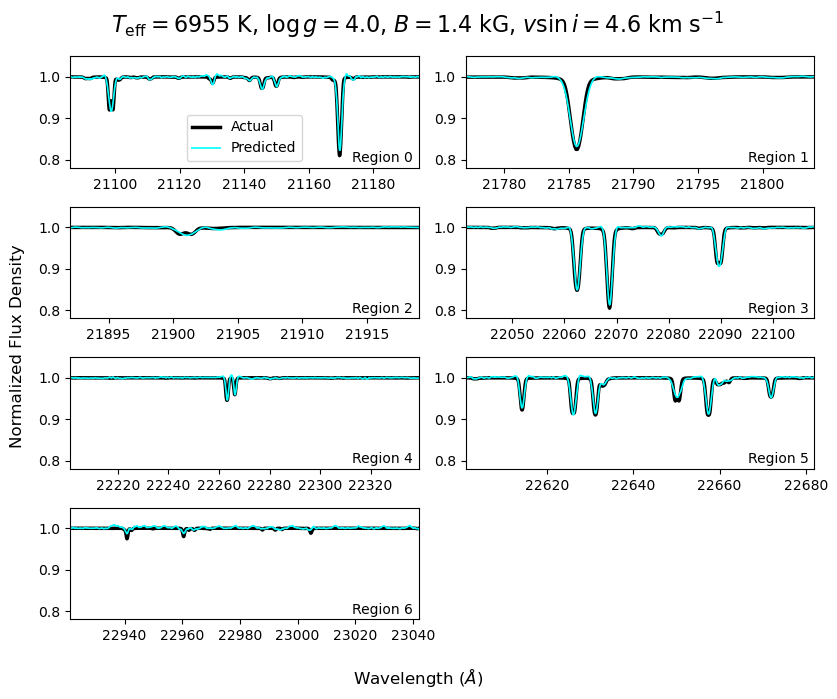

In [167]:
fig, axs = setup_regions_plot()
test_params = np.loadtxt("data/test_params.txt").T


#idx = 93
idx = 39
Teff = test_params[0, idx]
logg = test_params[1, idx]
B = test_params[2, idx]
vsini = test_params[3, idx]

for r in range(7):
    # retrieve the MoogStokesModel for these parameters
    fname = MoogStokesModel.make_model_fname(
            Teff = Teff,
            logg = logg,
            rK = 0,
            B = B,
            vsini = vsini,
            region = r,
            models_dir = "data/moog-stokes-train/",
            use_hash = False
        )
    xactual = np.loadtxt(fname).T[0]
    yactual = np.loadtxt(fname).T[1]
    size = int( region_sizes[r] )
    if len(yactual) > size: # truncate the end
        yactual = yactual[:size]
        xactual = xactual[:size]

    model_nn = moognn.make_moogstokes_model(
        Teff = Teff,
        logg = logg,
        rK = 0,
        B = B,
        vsini = vsini,
        region = r
    )

    axs[r].plot(xactual*1e4, yactual, label="Actual", color='k', zorder=0, linewidth=2.5)
    axs[r].plot(model_nn.x, model_nn.y, label="Predicted", color='cyan', linestyle='-', zorder=1, linewidth=1.2)
    axs[r].set_ylim(0.78, 1.05)

    if r == 0:
        axs[r].legend(loc="lower center")

fig.suptitle(r"$T_\mathrm{eff} = $" + "{:d}".format(int(Teff)) + r" K, " + r"$\log g = $" + "{:.1f}".format(logg) + r", " + r"$B = $" + "{:.1f}".format(B) + r" kG, " + r"$v\sin i = $" + "{:.1f}".format(vsini) + r" km s$^{-1}$", fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
test_params = np.loadtxt("data/test_params.txt").T
Ntest = len(test_params[0])
moognn = MoogStokesNN()

region_info = np.loadtxt("data/region_info.txt").T
region_sizes = region_info[1]

diffs_all = np.zeros(Ntest)
vars_all = np.zeros(Ntest)
for i in range(Ntest):

    meandiff = 0
    stderr = 0
    for r in range(7):
        # retrieve the MoogStokesModel for these parameters
        fname = MoogStokesModel.make_model_fname(
                Teff = test_params[0, i],
                logg = test_params[1, i],
                rK = 0,
                B = test_params[2, i],
                vsini = test_params[3, i],
                region = r,
                models_dir = "data/moog-stokes-train/",
                use_hash = False
            )
        yactual = np.loadtxt(fname).T[1]
        size = int( region_sizes[r] )
        if len(yactual) > size: # truncate the end
            yactual = yactual[:size]

        model_nn = moognn.make_moogstokes_model(
            Teff = test_params[0, i],
            logg = test_params[1, i],
            rK = 0,
            B = test_params[2, i],
            vsini = test_params[3, i],
            region = r
        )

        # percentage difference at each wavelength point
        diffs = 100 * (model_nn.y - yactual) / yactual
        meandiff += np.mean(np.abs(diffs))
        stderr += np.std(diffs)**2
    
    diffs_all[i] = meandiff / 7
    vars_all[i] = stderr / 7

stderrs_all = np.sqrt(vars_all)

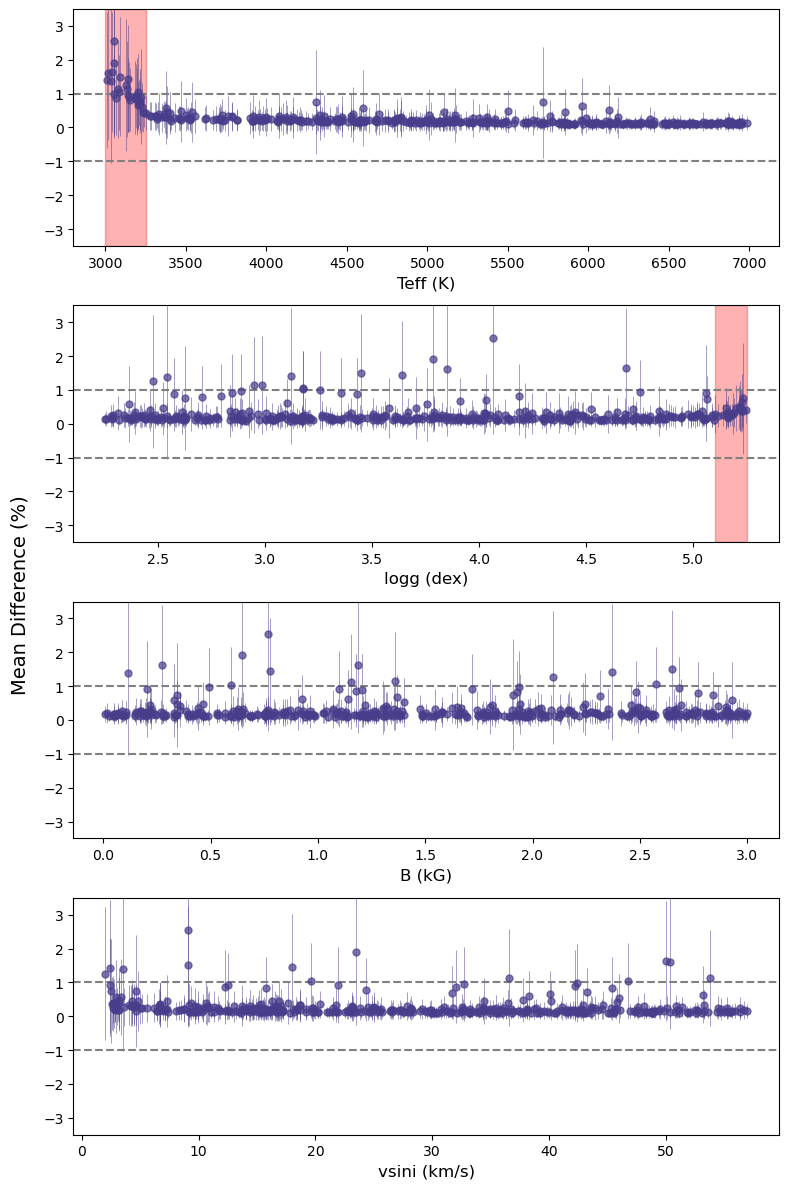

In [ ]:
N_params = 4

fig, axs = plt.subplots(N_params, 1, figsize=(8, 12))
param_names = scaler.param_order

for i in range(N_params):
    axs[i].errorbar(test_params[i], diffs_all, yerr=stderrs_all, fmt='o',
                    markersize=5, elinewidth=0.5, color='darkslateblue', alpha=0.7)
    axs[i].axhline(1, color='gray', linestyle='--', label='Loss = 0.01')
    axs[i].axhline(-1, color='gray', linestyle='--', label='Loss = 0.01')

    pname = param_names[i]
    axs[i].set_xlabel(pname + f" ({scaler.param_units[pname]})", fontsize=12)
    axs[i].set_ylim(-3.5,3.5)

axs[0].axvspan(3000, 3250, color='r', alpha=0.3)
axs[1].axvspan(5.1, 5.25, color='r', alpha=0.3)
fig.supylabel("Mean Difference (%)", fontsize=14)
plt.tight_layout()
#fig.savefig("figures/test_nn_hot.png", dpi=300, facecolor='white')
#fig.savefig(f"figures/fig-test_nn_region_{region}.png", dpi=300, facecolor='white')
fig.savefig(f"figures/nn_mean_diff.png", dpi=300, facecolor='white')
plt.show()

Large difference: 1.54 for [3.22100000e+03 5.05700004e+00 2.03999996e-01 2.41099930e+00]
Large difference: 2.21 for [5.96000000e+03 5.22500002e+00 1.13900000e+00 5.31770020e+01]
Large difference: 1.09 for [3.20900000e+03 5.06299996e+00 2.84299999e+00 4.32430000e+01]
Large difference: 1.76 for [3.04000000e+03 4.68500000e+00 2.73000002e-01 4.99640007e+01]
Large difference: 1.64 for [5.85300000e+03 5.19900000e+00 3.45000029e-01 3.43990002e+01]
Large difference: 1.45 for [5.50400000e+03 5.21099997e+00 4.65999961e-01 3.77819996e+01]
Large difference: 1.05 for [6.18600000e+03 5.18700004e+00 2.66000003e+00 1.36789999e+01]
Large difference: 1.21 for [5.76100000e+03 5.16400003e+00 1.31999999e+00 4.28670006e+01]
Large difference: 2.40 for [5.72000000e+03 5.23099995e+00 1.91100000e+00 4.63700104e+00]
Large difference: 1.85 for [6.13100000e+03 5.21700001e+00 1.39999998e+00 4.59519997e+01]


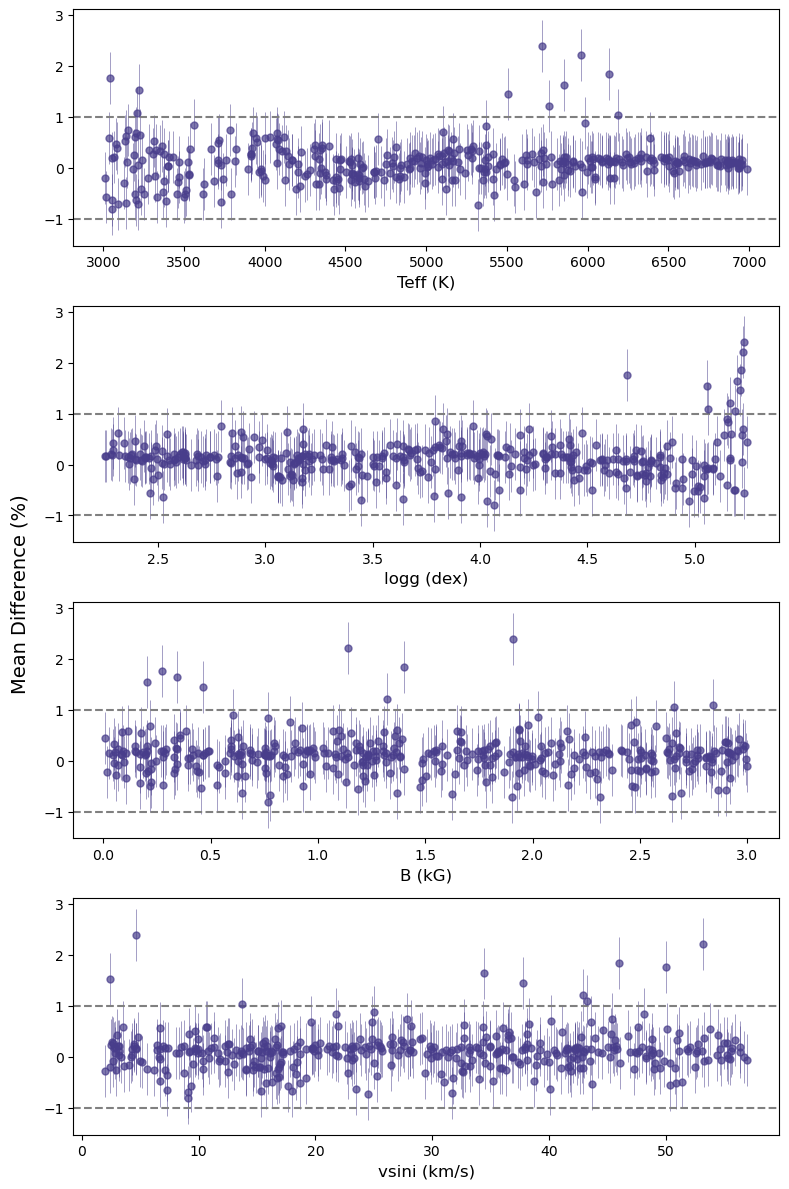

In [ ]:
# Calculate the loss for every set of parameters on the test set, and plot it as a function of each parameter to see if there are any trends in where the model is performing well or poorly.
test_diffs = []
test_params_phys = []
for idx in range(409): # number of training samples

    for r in range(7):
        data_test = MoogStokesTorchDataset(fname_test, region=r)
        x, y_actual = data_test[idx][0], data_test[idx][1]
        y_actual = y_actual.numpy()
        x = x.unsqueeze(0)  # add batch dimension
        p_phys = scaler.nn_to_physical(data_test[idx][0].numpy())

    with torch.no_grad():
        x = x.to(DEVICE)
        pred = model(x)
        y_pred = pred.cpu().numpy()[0]

    diffs = 100 * (y_pred - y_actual) / y_actual # percentage difference at each wavelength point
    meandiff = np.mean(diffs)
    stderr = np.std(diffs)

    test_diffs.append(meandiff)
    if np.abs(meandiff) > 1:
        print(f"Large difference: {meandiff:.2f} for {scaler.nn_to_physical(data_test[idx][0].numpy())}")

    p_phys = scaler.nn_to_physical(data_test[idx][0].numpy())
    test_params_phys.append(p_phys)

test_params_phys = np.array(test_params_phys)

N_params = test_params_phys.shape[1]

fig, axs = plt.subplots(N_params, 1, figsize=(8, 12))
param_names = scaler.param_order
for i in range(N_params):
    axs[i].errorbar(test_params_phys[:, i], test_diffs, yerr=stderr, fmt='o',
                    markersize=5, elinewidth=0.5, color='darkslateblue', alpha=0.7)
    axs[i].axhline(1, color='gray', linestyle='--', label='Loss = 0.01')
    axs[i].axhline(-1, color='gray', linestyle='--', label='Loss = 0.01')

    pname = param_names[i]
    axs[i].set_xlabel(pname + f" ({scaler.param_units[pname]})", fontsize=12)
    #axs[i].set_ylim(-1.1,1.1)
fig.supylabel("Mean Difference (%)", fontsize=14)
plt.tight_layout()
#fig.savefig("figures/test_nn_hot.png", dpi=300, facecolor='white')
fig.savefig(f"figures/fig-test_nn_region_{region}.png", dpi=300, facecolor='white')
plt.show()

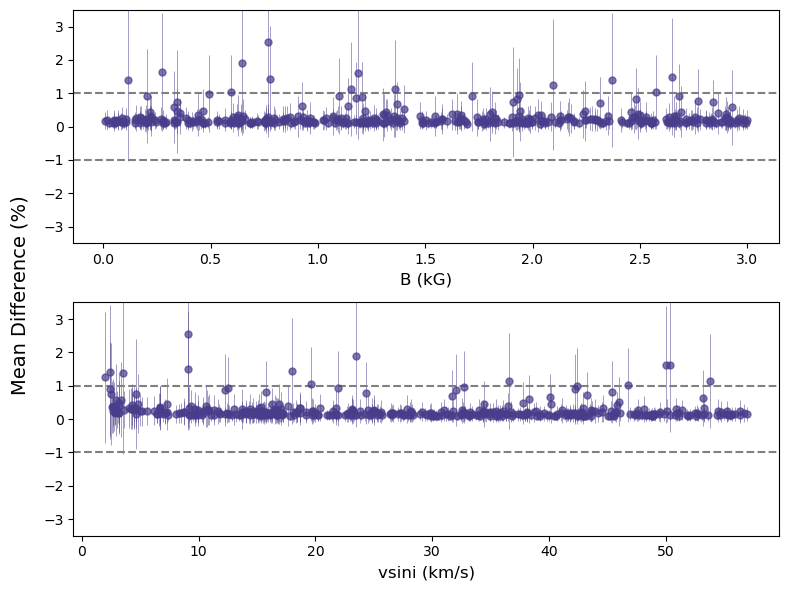

In [ ]:
N_params = 2

fig, axs = plt.subplots(2, 1, figsize=(8, 6))
param_names = scaler.param_order

for i in range(N_params):
    axs[i].errorbar(test_params[i+2], diffs_all, yerr=stderrs_all, fmt='o',
                    markersize=5, elinewidth=0.5, color='darkslateblue', alpha=0.7)
    axs[i].axhline(1, color='gray', linestyle='--', label='Loss = 0.01')
    axs[i].axhline(-1, color='gray', linestyle='--', label='Loss = 0.01')

    pname = param_names[i+2]
    axs[i].set_xlabel(pname + f" ({scaler.param_units[pname]})", fontsize=12)
    axs[i].set_ylim(-3.5,3.5)

fig.supylabel("Mean Difference (%)", fontsize=14)
plt.tight_layout()
#fig.savefig("figures/test_nn_hot.png", dpi=300, facecolor='white')
#fig.savefig(f"figures/fig-test_nn_region_{region}.png", dpi=300, facecolor='white')
fig.savefig(f"figures/nn_mean_diff-2.png", dpi=300, facecolor='white')
plt.show()

Large difference: 1.54 for [3.22100000e+03 5.05700004e+00 2.03999996e-01 2.41099930e+00]
Large difference: 2.21 for [5.96000000e+03 5.22500002e+00 1.13900000e+00 5.31770020e+01]
Large difference: 1.09 for [3.20900000e+03 5.06299996e+00 2.84299999e+00 4.32430000e+01]
Large difference: 1.76 for [3.04000000e+03 4.68500000e+00 2.73000002e-01 4.99640007e+01]
Large difference: 1.64 for [5.85300000e+03 5.19900000e+00 3.45000029e-01 3.43990002e+01]
Large difference: 1.45 for [5.50400000e+03 5.21099997e+00 4.65999961e-01 3.77819996e+01]
Large difference: 1.05 for [6.18600000e+03 5.18700004e+00 2.66000003e+00 1.36789999e+01]
Large difference: 1.21 for [5.76100000e+03 5.16400003e+00 1.31999999e+00 4.28670006e+01]
Large difference: 2.40 for [5.72000000e+03 5.23099995e+00 1.91100000e+00 4.63700104e+00]
Large difference: 1.85 for [6.13100000e+03 5.21700001e+00 1.39999998e+00 4.59519997e+01]


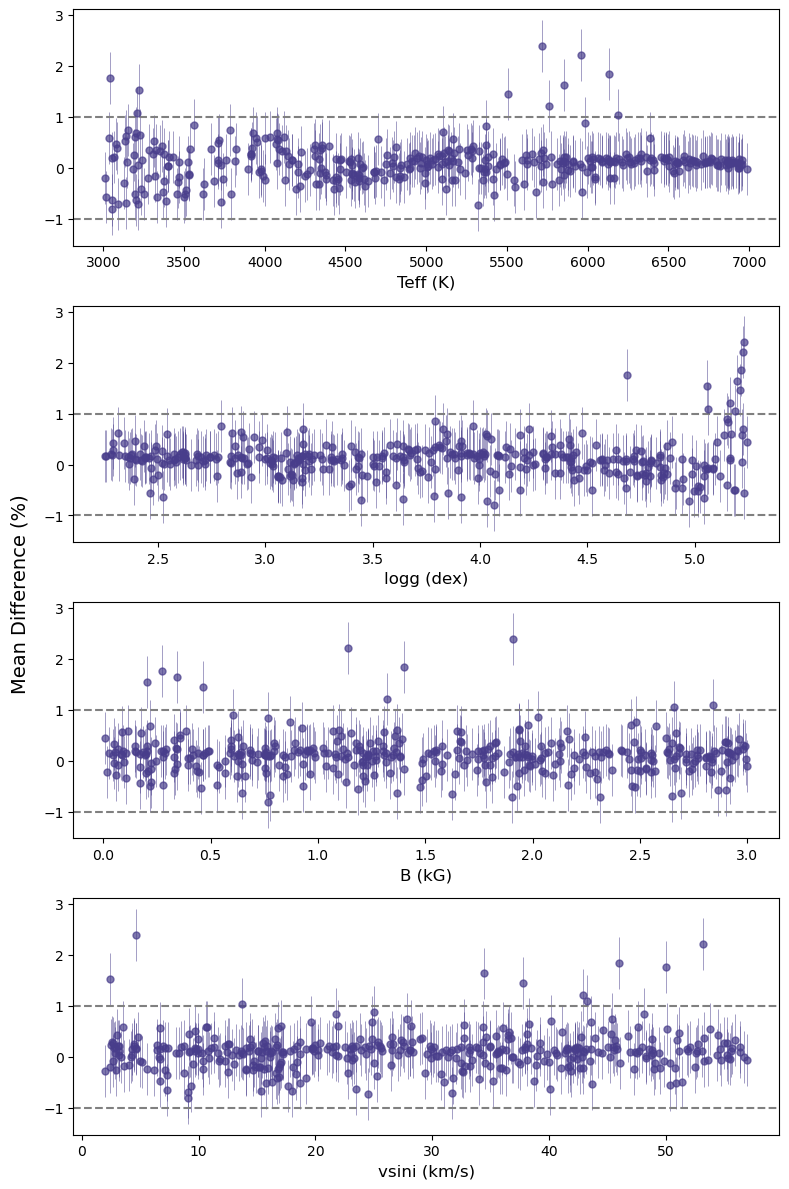

In [ ]:
# Calculate the loss for every set of parameters on the test set, and plot it as a function of each parameter to see if there are any trends in where the model is performing well or poorly.
test_diffs = []
test_params_phys = []
for idx in range(len(data_test)):
    x, y_actual = data_test[idx][0], data_test[idx][1]
    y_actual = y_actual.numpy()
    x = x.unsqueeze(0)  # add batch dimension

    with torch.no_grad():
        x = x.to(DEVICE)
        pred = model(x)
        y_pred = pred.cpu().numpy()[0]

    diffs = 100 * (y_pred - y_actual) / y_actual # percentage difference at each wavelength point
    meandiff = np.mean(diffs)
    stderr = np.std(diffs)

    test_diffs.append(meandiff)
    if np.abs(meandiff) > 1:
        print(f"Large difference: {meandiff:.2f} for {scaler.nn_to_physical(data_test[idx][0].numpy())}")

    p_phys = scaler.nn_to_physical(data_test[idx][0].numpy())
    test_params_phys.append(p_phys)

test_params_phys = np.array(test_params_phys)

N_params = test_params_phys.shape[1]

fig, axs = plt.subplots(N_params, 1, figsize=(8, 12))
param_names = scaler.param_order
for i in range(N_params):
    axs[i].errorbar(test_params_phys[:, i], test_diffs, yerr=stderr, fmt='o',
                    markersize=5, elinewidth=0.5, color='darkslateblue', alpha=0.7)
    axs[i].axhline(1, color='gray', linestyle='--', label='Loss = 0.01')
    axs[i].axhline(-1, color='gray', linestyle='--', label='Loss = 0.01')

    pname = param_names[i]
    axs[i].set_xlabel(pname + f" ({scaler.param_units[pname]})", fontsize=12)
    #axs[i].set_ylim(-1.1,1.1)
fig.supylabel("Mean Difference (%)", fontsize=14)
plt.tight_layout()
#fig.savefig("figures/test_nn_hot.png", dpi=300, facecolor='white')
fig.savefig(f"figures/fig-test_nn_region_{region}.png", dpi=300, facecolor='white')
plt.show()

In [29]:
moognn = MoogStokesNN()

t1 = time.time()
t2 = time.time()
print(f"Time to generate one model: {t2 - t1:.4f} seconds")

Time to generate one model: 0.0000 seconds


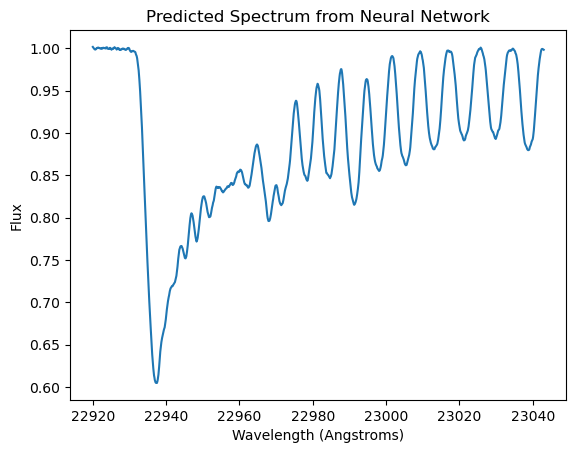

In [34]:
testmodel = moognn.make_moogstokes_model(Teff=4000, logg=4.25, rK=0, B=1.0, vsini=37, region=6)

plt.figure()
plt.plot(testmodel.x, testmodel.y)
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux")
plt.title("Predicted Spectrum from Neural Network")
plt.show()